# **Transformer Models Evaluation**

## **Checking for GPU**

In [1]:
import torch
import os

print(f"Current Node: {os.uname()[1]}") # Should say node001
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"Using Device: {torch.cuda.get_device_name(0)}")

Current Node: node001
GPU Available: True
Using Device: NVIDIA A30


In [2]:
import logging
from transformers import logging as hf_logging

#This tells the library to stop shouting about the Mistral regex
hf_logging.set_verbosity_error()

## **1. Importing Required Modules**

In [3]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

## **2. Paths & Configuration**

In [4]:
#Since the notebook is in /notebooks, we move up one level to the root
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "humaid_processed.csv")
XLMR_PATH = os.path.join(ROOT_DIR, "trained_models", "xlm_roberta_final")
MURIL_PATH = os.path.join(ROOT_DIR, "trained_models", "muril_final")
MAL_DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "malayalam_test_100.csv")
HINDI_DATA_PATH = os.path.join(ROOT_DIR, "datasets", "processed", "hindi_test_100.csv")

LABEL_NAMES = ['Situational Awareness', 'Critical Rescue', 'Volunteering and Donations', 'Irrelevant', 'Resource Requests']
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}
id2label = {i: label for i, label in enumerate(LABEL_NAMES)}

In [5]:
#Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluation running on: {device}")

Evaluation running on: cuda


## **3. Load Test Data**

In [6]:
print("Loading humaid_processed.csv...")
df = pd.read_csv(DATA_PATH)
print("Loading malayalam_test_100.csv...")
mal_df = pd.read_csv(MAL_DATA_PATH)
print("Loading hindi_test_100.csv...")
hi_df = pd.read_csv(HINDI_DATA_PATH)

# Map labels to integers and isolate the test set
df['label'] = df['target_label'].map(label2id)
mal_df['label'] = mal_df['target_label'].map(label2id)
hi_df['label'] = hi_df['target_label'].map(label2id)

df = df.dropna(subset=['label'])
test_df = df[df['split'] == 'test'].reset_index(drop=True)

texts = test_df['clean_text'].astype(str).tolist()
mal_texts = mal_df['malayalam_text'].astype(str).tolist()
hi_texts = hi_df['hindi_text'].astype(str).tolist()

true_labels = test_df['label'].astype(int).tolist()
mal_true_labels = mal_df['label'].tolist()
hi_true_labels = hi_df['label'].tolist()

print(f"Total test samples: {len(texts)}")

Loading humaid_processed.csv...
Loading malayalam_test_100.csv...
Loading hindi_test_100.csv...
Total test samples: 14711


In [7]:
def evaluate_model(model_path, model_name, texts, true_labels, batch_size=32):
    """Loads a model, runs inference in batches, and returns predictions and metrics."""
    print(f"\n--- Starting Evaluation for {model_name} ---")
    
    if not os.path.exists(model_path):
        print(f"ERROR: Model path not found -> {model_path}")
        return None

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    all_predictions = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            all_predictions.extend(predictions.cpu().numpy())
            
            if i % 640 == 0 and i > 0:
                print(f"Processed {i}/{len(texts)} samples...")

    # Calculate core metrics
    acc = accuracy_score(true_labels, all_predictions)
    macro_f1 = f1_score(true_labels, all_predictions, average='macro')
    
    print(f"✓ {model_name} Evaluation Complete. Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    
    return {
        "name": model_name,
        "predictions": all_predictions,
        "accuracy": acc,
        "macro_f1": macro_f1
    }

In [8]:
# Run inference for both models
xlmr_results = evaluate_model(XLMR_PATH, "XLM-RoBERTa", texts, true_labels)


--- Starting Evaluation for XLM-RoBERTa ---
Processed 640/14711 samples...
Processed 1280/14711 samples...
Processed 1920/14711 samples...
Processed 2560/14711 samples...
Processed 3200/14711 samples...
Processed 3840/14711 samples...
Processed 4480/14711 samples...
Processed 5120/14711 samples...
Processed 5760/14711 samples...
Processed 6400/14711 samples...
Processed 7040/14711 samples...
Processed 7680/14711 samples...
Processed 8320/14711 samples...
Processed 8960/14711 samples...
Processed 9600/14711 samples...
Processed 10240/14711 samples...
Processed 10880/14711 samples...
Processed 11520/14711 samples...
Processed 12160/14711 samples...
Processed 12800/14711 samples...
Processed 13440/14711 samples...
Processed 14080/14711 samples...
✓ XLM-RoBERTa Evaluation Complete. Accuracy: 0.8498 | Macro F1: 0.7761


In [9]:
muril_results = evaluate_model(MURIL_PATH, "MuRIL", texts, true_labels)


--- Starting Evaluation for MuRIL ---
Processed 640/14711 samples...
Processed 1280/14711 samples...
Processed 1920/14711 samples...
Processed 2560/14711 samples...
Processed 3200/14711 samples...
Processed 3840/14711 samples...
Processed 4480/14711 samples...
Processed 5120/14711 samples...
Processed 5760/14711 samples...
Processed 6400/14711 samples...
Processed 7040/14711 samples...
Processed 7680/14711 samples...
Processed 8320/14711 samples...
Processed 8960/14711 samples...
Processed 9600/14711 samples...
Processed 10240/14711 samples...
Processed 10880/14711 samples...
Processed 11520/14711 samples...
Processed 12160/14711 samples...
Processed 12800/14711 samples...
Processed 13440/14711 samples...
Processed 14080/14711 samples...
✓ MuRIL Evaluation Complete. Accuracy: 0.8356 | Macro F1: 0.7178


## **4. Reporting & Visualizations**

In [10]:
def plot_confusion_matrix(true_labels, predictions, model_name):
    """Generates a highly readable confusion matrix heatmap."""
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, pad=15)
    plt.ylabel('Actual Category', fontsize=12)
    plt.xlabel('Predicted Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
#Print Detailed Classification Reports
print("\n" + "="*60)
print("XLM-RoBERTa CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_labels, xlmr_results["predictions"], target_names=LABEL_NAMES))


XLM-RoBERTa CLASSIFICATION REPORT
                            precision    recall  f1-score   support

     Situational Awareness       0.87      0.86      0.87      6679
           Critical Rescue       0.91      0.94      0.92      2167
Volunteering and Donations       0.85      0.91      0.88      4133
                Irrelevant       0.68      0.55      0.61      1216
         Resource Requests       0.63      0.59      0.61       516

                  accuracy                           0.85     14711
                 macro avg       0.79      0.77      0.78     14711
              weighted avg       0.85      0.85      0.85     14711



In [12]:
print("\n" + "="*60)
print("MuRIL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_labels, muril_results["predictions"], target_names=LABEL_NAMES))


MuRIL CLASSIFICATION REPORT
                            precision    recall  f1-score   support

     Situational Awareness       0.85      0.87      0.86      6679
           Critical Rescue       0.89      0.95      0.92      2167
Volunteering and Donations       0.81      0.92      0.86      4133
                Irrelevant       0.70      0.38      0.49      1216
         Resource Requests       0.69      0.34      0.46       516

                  accuracy                           0.84     14711
                 macro avg       0.79      0.69      0.72     14711
              weighted avg       0.83      0.84      0.82     14711



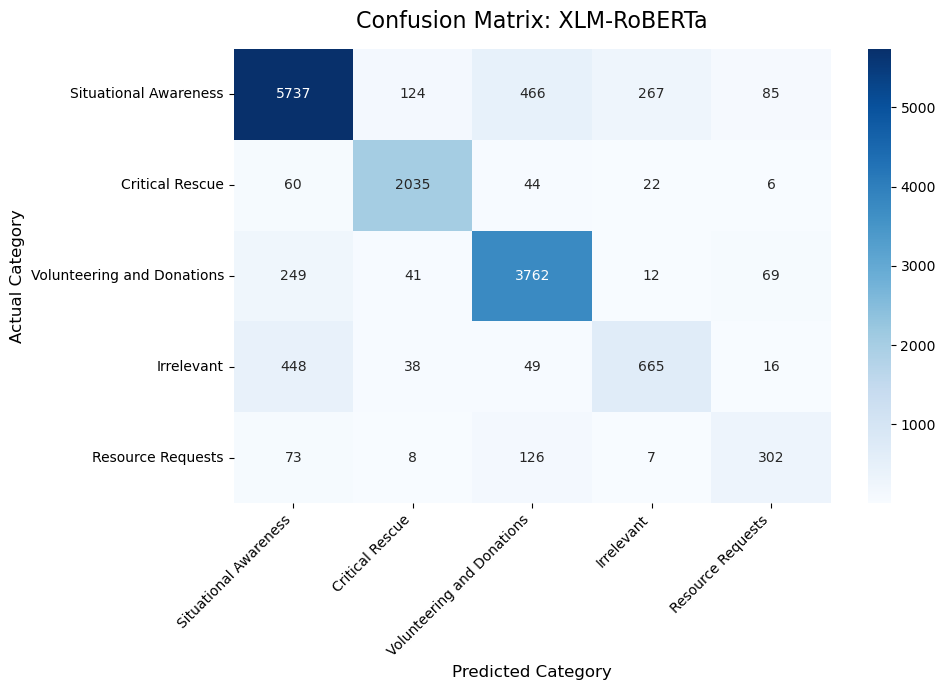

In [13]:
#Plot Confusion Matrices
plot_confusion_matrix(true_labels, xlmr_results["predictions"], xlmr_results["name"])

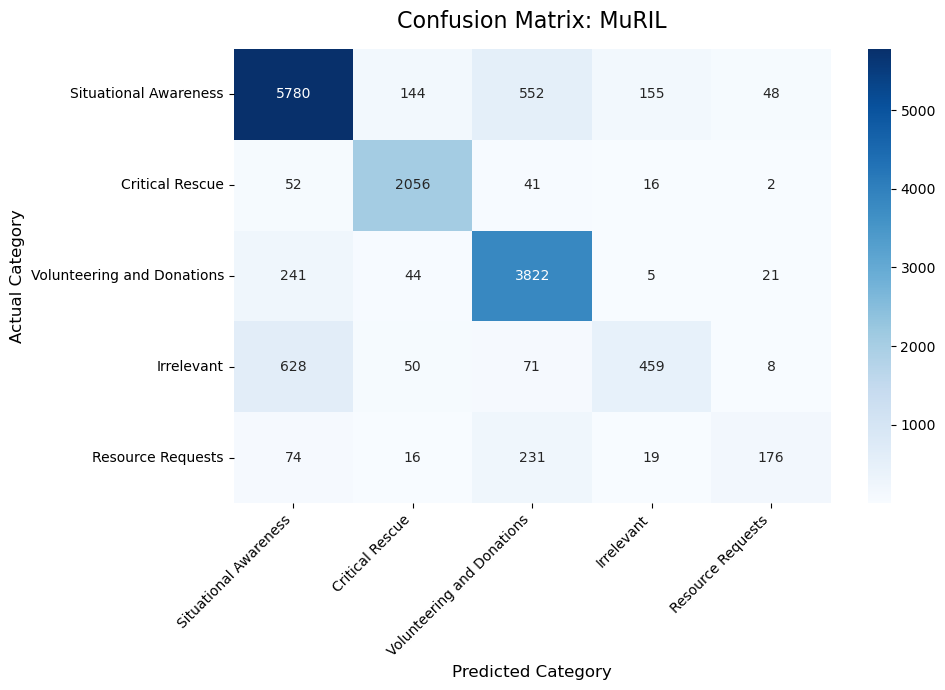

In [14]:
plot_confusion_matrix(true_labels, muril_results["predictions"], muril_results["name"])

In [15]:
#Plot Direct Comparison Chart
metrics_data = {
    'Model': ['XLM-RoBERTa', 'XLM-RoBERTa', 'MuRIL', 'MuRIL'],
    'Metric': ['Accuracy', 'Macro F1', 'Accuracy', 'Macro F1'],
    'Score': [
        xlmr_results["accuracy"], xlmr_results["macro_f1"], 
        muril_results["accuracy"], muril_results["macro_f1"]
    ]
}
comp_df = pd.DataFrame(metrics_data)

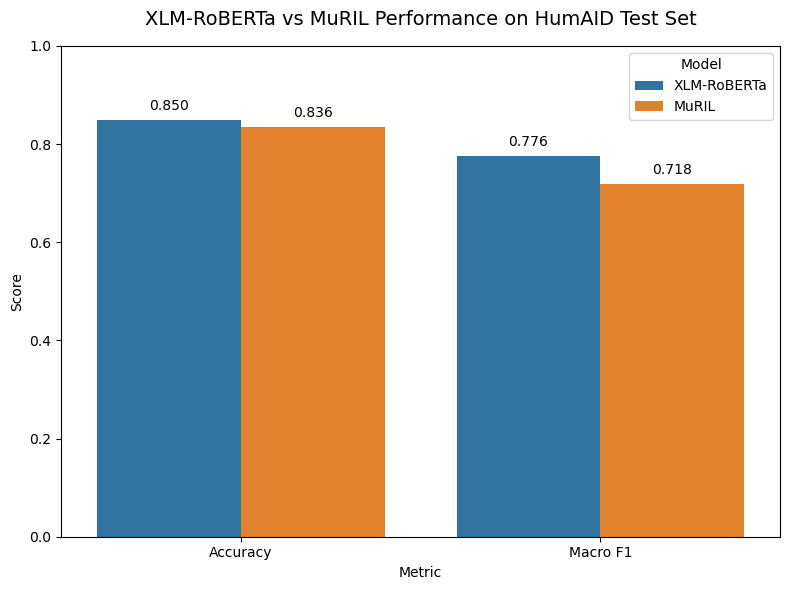

In [16]:
plt.figure(figsize=(8, 6))
sns.barplot(data=comp_df, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#ff7f0e'])
plt.title('XLM-RoBERTa vs MuRIL Performance on HumAID Test Set', fontsize=14, pad=15)
plt.ylim(0, 1.0) # Set Y-axis from 0 to 1 for standard percentage view
plt.ylabel('Score')

#Add exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

## **Evaluating XLM-R and MuRIL on Malayalam samples...**

In [17]:
print(f"Evaluating XLM-R and MuRIL on {len(mal_texts)} Malayalam samples...")
xlmr_mal_results = evaluate_model(XLMR_PATH, "XLM-RoBERTa (Malayalam)", mal_texts, mal_true_labels)

Evaluating XLM-R and MuRIL on 100 Malayalam samples...

--- Starting Evaluation for XLM-RoBERTa (Malayalam) ---
✓ XLM-RoBERTa (Malayalam) Evaluation Complete. Accuracy: 0.6400 | Macro F1: 0.6438


In [20]:
xlmr_mal_results = evaluate_model(XLMR_PATH, "XLM-RoBERTa (Malayalam)", mal_texts, mal_true_labels)
muril_mal_results = evaluate_model(MURIL_PATH, "MuRIL (Malayalam)", mal_texts, mal_true_labels)


--- Starting Evaluation for XLM-RoBERTa (Malayalam) ---
✓ XLM-RoBERTa (Malayalam) Evaluation Complete. Accuracy: 0.6400 | Macro F1: 0.6438

--- Starting Evaluation for MuRIL (Malayalam) ---
✓ MuRIL (Malayalam) Evaluation Complete. Accuracy: 0.5600 | Macro F1: 0.5056


In [21]:
print("\n" + "="*50)
print(f"{'MODEL':<25} | {'ACCURACY':<10}")
print("-" * 40)
print(f"{'XLM-RoBERTa':<25} | {xlmr_mal_results['accuracy']:.4f}")
print(f"{'MuRIL':<25} | {muril_mal_results['accuracy']:.4f}")
print("="*50)


MODEL                     | ACCURACY  
----------------------------------------
XLM-RoBERTa               | 0.6400
MuRIL                     | 0.5600


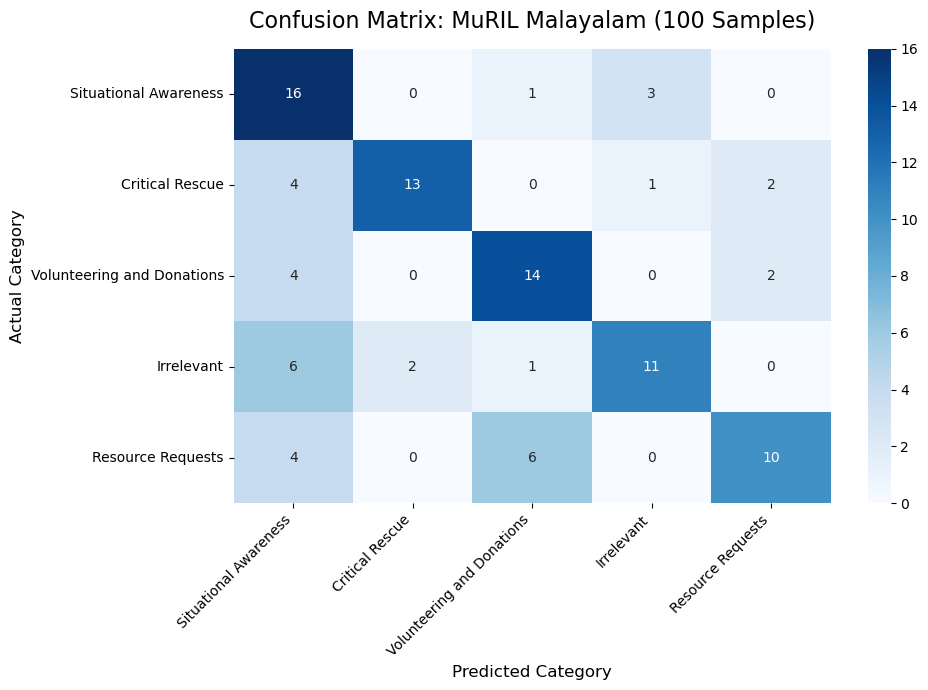

In [23]:
plot_confusion_matrix(mal_true_labels, xlmr_mal_results["predictions"], "MuRIL Malayalam (100 Samples)")

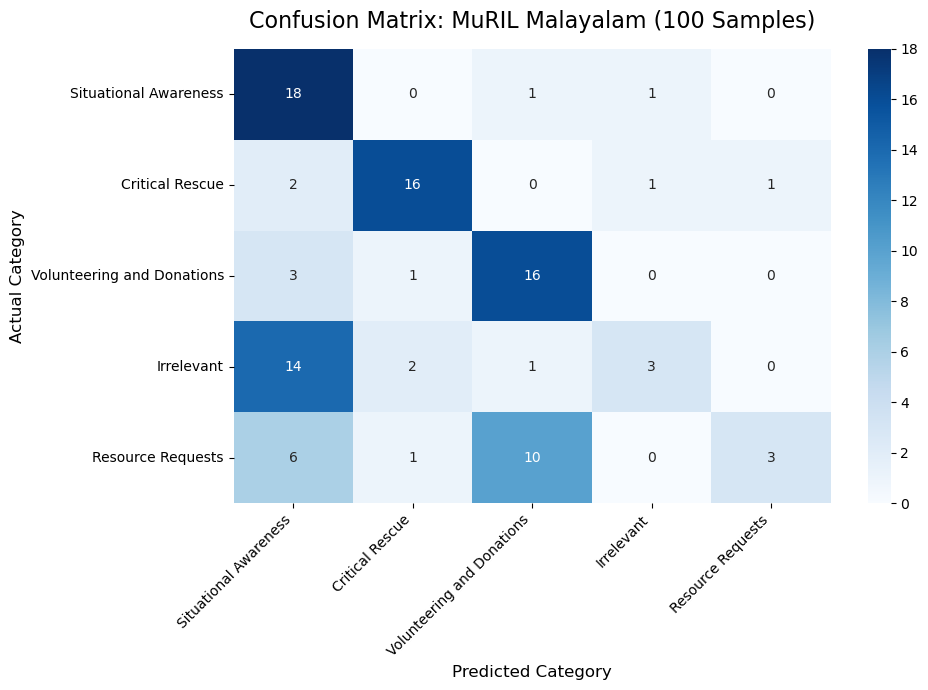

In [24]:
plot_confusion_matrix(mal_true_labels, muril_mal_results["predictions"], "MuRIL Malayalam (100 Samples)")

## **Evaluating XLM-R and MuRIL on Hindi samples...**

In [25]:
print(f"Evaluating XLM-R and MuRIL on {len(hi_texts)} Hindi samples...")

# Inference using your evaluate_model function
xlmr_hi_results = evaluate_model(XLMR_PATH, "XLM-RoBERTa (Hindi)", hi_texts, hi_true_labels)

Evaluating XLM-R and MuRIL on 100 Hindi samples...

--- Starting Evaluation for XLM-RoBERTa (Hindi) ---
✓ XLM-RoBERTa (Hindi) Evaluation Complete. Accuracy: 0.6200 | Macro F1: 0.6181


In [26]:
muril_hi_results = evaluate_model(MURIL_PATH, "MuRIL (Hindi)", hi_texts, hi_true_labels)


--- Starting Evaluation for MuRIL (Hindi) ---
✓ MuRIL (Hindi) Evaluation Complete. Accuracy: 0.5300 | Macro F1: 0.4759


In [27]:
print("\n" + "="*50)
print(f"{'MODEL (HINDI)':<25} | {'ACCURACY':<10}")
print("-" * 40)
print(f"{'XLM-RoBERTa':<25} | {xlmr_hi_results['accuracy']:.4f}")
print(f"{'MuRIL':<25} | {muril_hi_results['accuracy']:.4f}")
print("="*50)


MODEL (HINDI)             | ACCURACY  
----------------------------------------
XLM-RoBERTa               | 0.6200
MuRIL                     | 0.5300


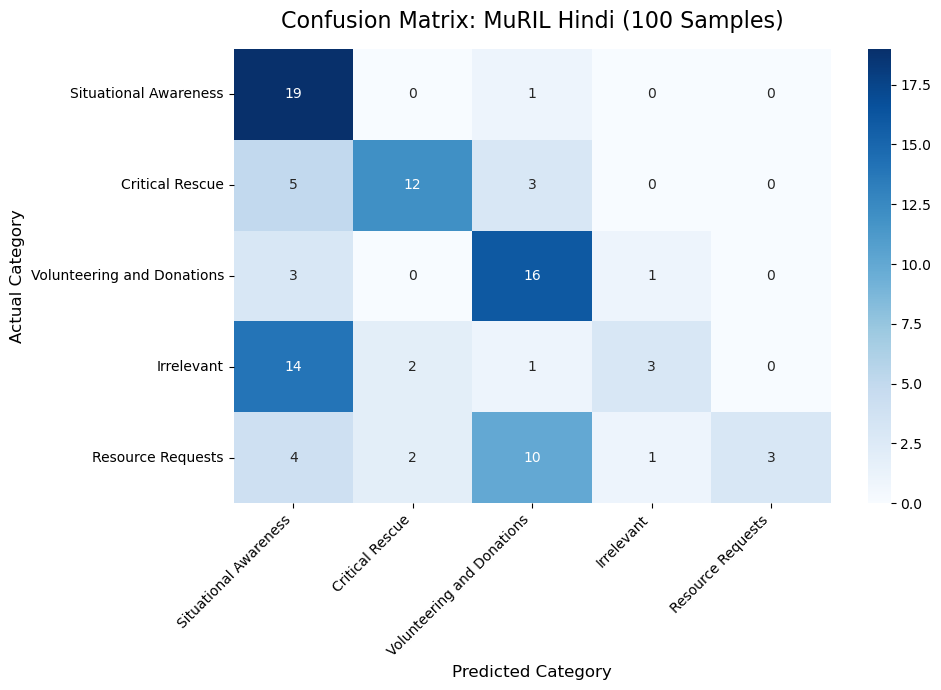

In [28]:
plot_confusion_matrix(hi_true_labels, muril_hi_results["predictions"], "MuRIL Hindi (100 Samples)")